# Product Reorder Prediction 


## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


## 2. Load and merge the data

Here the four CSV files are loaded and combined into one working dataframe for modelling.

The merged `data` table links:
- each order
- the products in that order
- the user who placed it
- the product category

In [2]:
# Load data
users = pd.read_csv("Dataset/users.csv")
products = pd.read_csv("Dataset/products.csv")
orders = pd.read_csv("Dataset/orders.csv")
order_products = pd.read_csv("Dataset/order_products.csv")

# Merge everything
data = order_products.merge(orders, on="order_id") \
                     .merge(products, on="product_id")


In [3]:
print("Merged dataset shape:", data.shape)
display(data.head())

Merged dataset shape: (19430, 6)


,order_id,product_id,reordered,user_id,order_number,category
0,1,140,0,1,1,dairy
1,1,100,0,1,1,snacks
2,1,63,0,1,1,snacks
3,2,107,0,1,2,drinks
4,2,50,0,1,2,drinks


## 3. Create model features

This section builds the features used by the recommendation model:

- `user_total_orders`: how many orders a user has placed
- `product_total_purchases`: how often a product has been bought overall
- `product_reorder_rate`: how often a product is reordered
- `user_product_purchase_count`: how many times a specific user has bought a specific product

In [4]:
# User-level feature
user_order_counts = orders.groupby("user_id")["order_id"].count()
data["user_total_orders"] = data["user_id"].map(user_order_counts)

# Product-level features
product_purchase_counts = data.groupby("product_id").size()
product_reorder_rates = data.groupby("product_id")["reordered"].mean()

data["product_total_purchases"] = data["product_id"].map(product_purchase_counts)
data["product_reorder_rate"] = data["product_id"].map(product_reorder_rates)

# User–product interaction feature
user_product_counts = (
    data.groupby(["user_id", "product_id"])
        .size()
        .rename("user_product_purchase_count")
        .reset_index()
)

data = data.merge(
    user_product_counts,
    on=["user_id", "product_id"],
    how="left"
)


In [5]:
display(
    data[
        [
            "user_id",
            "product_id",
            "category",
            "reordered",
            "user_total_orders",
            "product_total_purchases",
            "product_reorder_rate",
            "user_product_purchase_count",
        ]
    ].head()
)

,user_id,product_id,category,reordered,user_total_orders,product_total_purchases,product_reorder_rate,user_product_purchase_count
0,1,140,dairy,0,13,91,0.494505,1
1,1,100,snacks,0,13,112,0.419643,4
2,1,63,snacks,0,13,127,0.409449,1
3,1,107,drinks,0,13,144,0.513889,5
4,1,50,drinks,0,13,119,0.420168,6


## 4. Modelling data

The feature matrix `X` contains the predictor variables, and `y` is the target variable that indicates whether a product was reordered.

In [6]:
features = [
    "user_total_orders",
    "product_total_purchases",
    "product_reorder_rate",
    "user_product_purchase_count",
    "category"
]

X = data[features]
y = data["reordered"]


In [7]:
print("Feature columns:")
print(features)
print("\nTarget distribution:")
display(y.value_counts(normalize=True).rename("proportion"))

Feature columns:
['user_total_orders', 'product_total_purchases', 'product_reorder_rate', 'user_product_purchase_count', 'category']

Target distribution:


reordered
0    0.558003
1    0.441997
Name: proportion, dtype: float64

## 5. Build the preprocessing and modelling pipeline

The pipeline:
- passes numerical features through unchanged
- one-hot encodes the product category
- trains a logistic regression classifier

This keeps preprocessing and model training together in one workflow.

In [8]:
numeric_features = [
    "user_total_orders",
    "product_total_purchases",
    "product_reorder_rate",
    "user_product_purchase_count"
]

categorical_features = ["category"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)


## 6. Data Splitting and Model Training

The data is split into training and test sets, then the logistic regression pipeline is fitted.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model.fit(X_train, y_train)

print("Model trained successfully.")


Model trained successfully.


## 7. Evaluate model performance

These cells assess how well the model performs on the test set using:
- accuracy
- precision
- recall
- F1-score
- ROC-AUC
- confusion matrix
- ROC curve

Evaluation Metrics
Accuracy:  0.7810
Precision: 0.7440
Recall:    0.7695
F1-score:  0.7565
ROC-AUC:   0.8547

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.79      0.80      2168
           1       0.74      0.77      0.76      1718

    accuracy                           0.78      3886
   macro avg       0.78      0.78      0.78      3886
weighted avg       0.78      0.78      0.78      3886



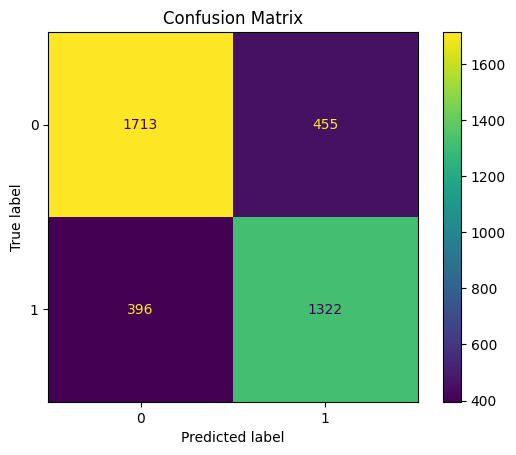

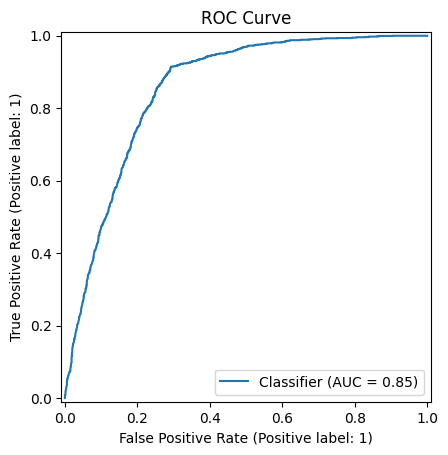

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report
)

# Predictions on test set
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Evaluation Metrics")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC Curve")
plt.show()

### Probability distribution plot

This plot helps show how confidently the model separates reordered and non-reordered examples.

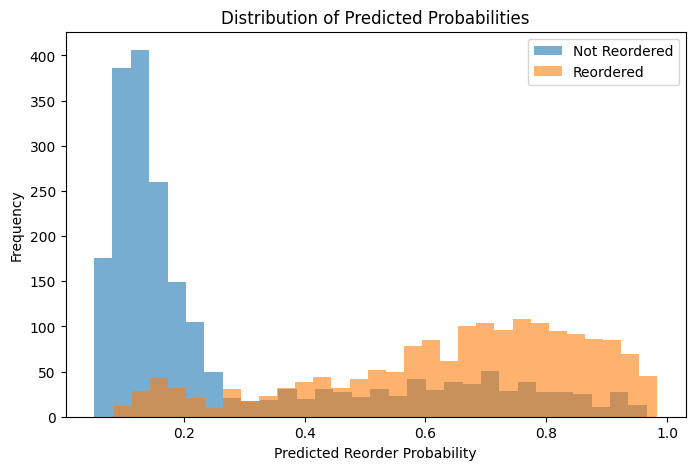

In [11]:
# Predicted probability distributions
results_df = pd.DataFrame({
    "actual_reordered": y_test.values,
    "predicted_probability": y_prob
})

plt.figure(figsize=(8, 5))

plt.hist(
    results_df[results_df["actual_reordered"] == 0]["predicted_probability"],
    bins=30,
    alpha=0.6,
    label="Not Reordered"
)

plt.hist(
    results_df[results_df["actual_reordered"] == 1]["predicted_probability"],
    bins=30,
    alpha=0.6,
    label="Reordered"
)

plt.xlabel("Predicted Reorder Probability")
plt.ylabel("Frequency")
plt.title("Distribution of Predicted Probabilities")
plt.legend()
plt.show()

### Coefficient inspection

Because the model is logistic regression, the fitted coefficients can be inspected to understand which features push predictions up or down.


Top Positive Features
                             feature  coefficient
2          num__product_reorder_rate     2.058062
3   num__user_product_purchase_count     0.408767
5                cat__category_dairy     0.092025
6               cat__category_drinks     0.070883
1       num__product_total_purchases    -0.004382
10              cat__category_snacks    -0.016048
0             num__user_total_orders    -0.057130
4               cat__category_bakery    -0.116725
8                cat__category_fruit    -0.130879
11          cat__category_vegetables    -0.227663

Top Negative Features
                         feature  coefficient
5            cat__category_dairy     0.092025
6           cat__category_drinks     0.070883
1   num__product_total_purchases    -0.004382
10          cat__category_snacks    -0.016048
0         num__user_total_orders    -0.057130
4           cat__category_bakery    -0.116725
8            cat__category_fruit    -0.130879
11      cat__category_vegetables    

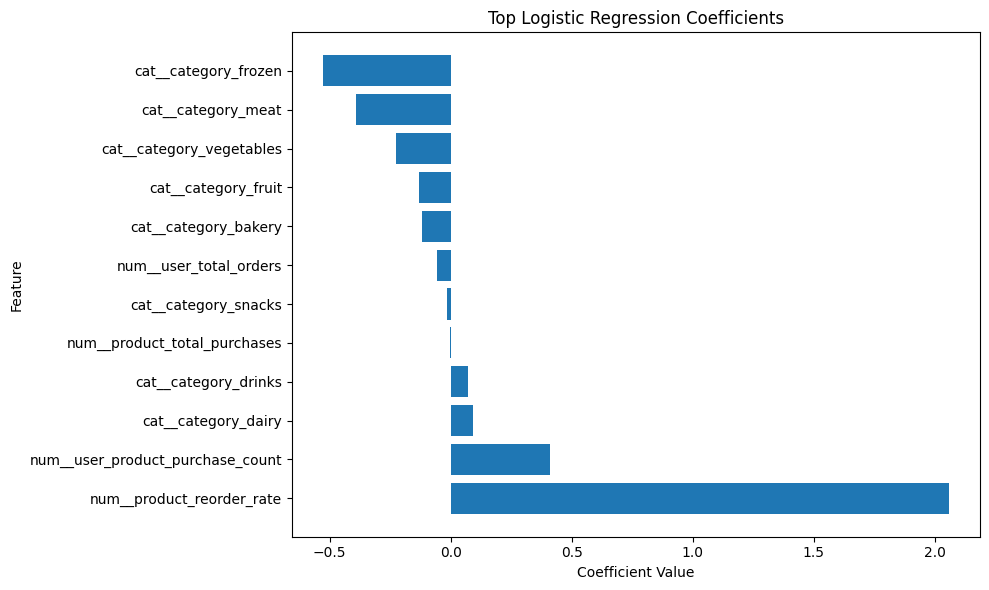

In [12]:
# Get feature names after preprocessing
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

# Get logistic regression coefficients
coefficients = model.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coef_df = coef_df.sort_values("coefficient", ascending=False)

print("\nTop Positive Features")
print(coef_df.head(10))

print("\nTop Negative Features")
print(coef_df.tail(10))

# Plot top coefficients
top_features = pd.concat([coef_df.head(10), coef_df.tail(10)])

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["coefficient"])
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Top Logistic Regression Coefficients")
plt.tight_layout()
plt.show()

### Ranked predicted probabilities

This gives a quick view of how the model's predicted reorder probabilities are distributed across the test samples.

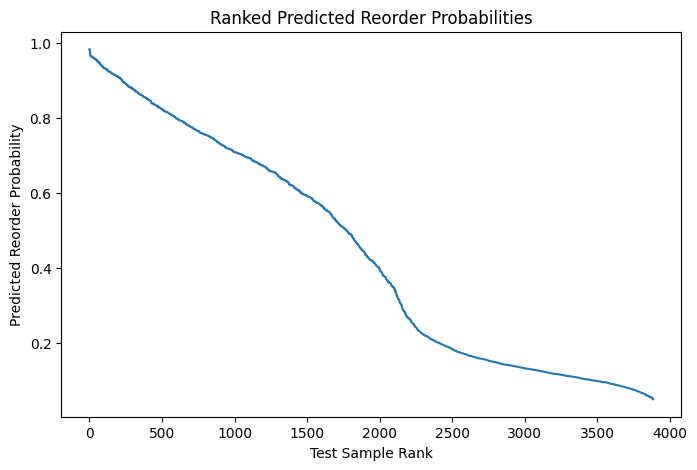

In [13]:
# Sort by predicted probability
sorted_probs = np.sort(y_prob)[::-1]

plt.figure(figsize=(8, 5))
plt.plot(sorted_probs)
plt.xlabel("Test Sample Rank")
plt.ylabel("Predicted Reorder Probability")
plt.title("Ranked Predicted Reorder Probabilities")
plt.show()

## 8. Prototype recommendation function

This function scores every product for a given user and returns the products with the highest predicted reorder probabilities.

In [14]:
def recommend_products_for_user(user_id, top_n=5):
    user_data = products.copy()

    user_data["user_id"] = user_id

    user_total_orders = orders[orders["user_id"] == user_id].shape[0]
    user_data["user_total_orders"] = user_total_orders

    user_product_counts = (
        data[data["user_id"] == user_id]
        .groupby("product_id")
        .size()
        .to_dict()
    )

    user_data["user_product_purchase_count"] = user_data["product_id"].map(
        user_product_counts
    ).fillna(0)

    user_data["product_total_purchases"] = user_data["product_id"].map(
        product_purchase_counts
    )

    user_data["product_reorder_rate"] = user_data["product_id"].map(
        product_reorder_rates
    )

    X_user = user_data[features]

    user_data["reorder_probability"] = model.predict_proba(X_user)[:, 1]

    recommendations = user_data.sort_values(
        "reorder_probability", ascending=False
    ).head(top_n)

    return recommendations[
        ["product_id", "category", "reorder_probability"]
    ]


### Example recommendation

An example is shown below for `user_id=60`.

In [15]:
print(recommend_products_for_user(user_id=60, top_n=5))


    product_id    category  reorder_probability
28          29      frozen             0.957012
63          64       dairy             0.932690
40          41  vegetables             0.857090
26          27      drinks             0.788623
72          73       dairy             0.760778


## 9. Export model 

These cells save the trained model and the supporting data needed later for inference in a separate script or application.

In [9]:
import joblib

joblib.dump(model, "reorder_model.joblib")
joblib.dump(product_purchase_counts, "product_purchase_counts.joblib")
joblib.dump(product_reorder_rates, "product_reorder_rates.joblib")

products.to_csv("products.csv", index=False)
orders.to_csv("orders.csv", index=False)

print("Model and artefacts exported successfully.")


Model and artefacts exported successfully.


In [10]:
user_product_counts = (
    data.groupby(["user_id", "product_id"])
        .size()
        .rename("user_product_purchase_count")
        .reset_index()
)

user_product_counts.to_csv(
    "user_product_purchase_counts.csv",
    index=False
)
